In [27]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
import seaborn as sns
import plotly as py
import plotly.express as px
import config
from data_utils import best_players_plots, table_simulation, expected_stats_vs_actuals, sort_data, colors_config

In [2]:
data = pd.read_parquet(config.TIDY_DATA_PATH)

In [3]:
data.head()

,name,position,xP,assists,bonus,bps,clean_sheets,creativity,element,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,own_goals,penalties_missed,penalties_saved,red_cards,saves,selected,starts,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,gw,code,season,date,team_score,opp_score,score_diff,player_id,shots,xg_chain,xg_buildup,key_passes,team_points,opp_points,team_expected_points,opp_expected_points,team_goals,opp_goals,team_xg,opp_xg,team_np_xg,opp_np_xg,team_np_xg_difference,opp_np_xg_difference,team_ppda,opp_ppda,team_deep_completions,opp_deep_completions,team_match_np_xg_diff,ppda_diff,understat
0,Andy Lonergan,GK,1.5,0,0,0,0,0.0,760,0.0,0.0,0.0,0.0,0,0,0.0,0.0,2023-04-22T14:00:00Z,0,7,0,0,0,0,0,0.0,0,0,0,0,0,0,4.0,False,0,32,11948,2223,2023-04-22,0,0,0,0,0.0,0.0,0.0,0.0,1.0,1.0,1.3073,1.1771,0.0,0.0,0.433712,0.368137,0.433712,0.368137,0.065575,-0.065575,8.818182,9.437500,3.0,5.0,0.065575,-0.619318,0.0
1,Andy Lonergan,GK,-0.5,0,0,0,0,0.0,760,0.0,0.0,0.0,0.0,0,0,0.0,0.0,2023-04-27T18:45:00Z,0,15,0,0,0,0,0,33.0,0,0,0,17,18,1,4.0,True,0,33,11948,2223,2023-04-27,1,4,-3,0,0.0,0.0,0.0,0.0,0.0,3.0,0.1780,2.7298,1.0,4.0,0.777008,2.863680,0.777008,2.863680,-2.086672,2.086672,11.363636,9.000000,6.0,9.0,-2.086672,2.363636,0.0
2,Andy Lonergan,GK,0.0,0,0,0,0,0.0,760,0.0,0.0,0.0,0.0,0,0,0.0,0.0,2023-05-01T19:00:00Z,0,10,0,0,0,0,0,84.0,0,0,0,19,25,6,4.0,False,0,34,11948,2223,2023-05-01,2,2,0,0,0.0,0.0,0.0,0.0,1.0,1.0,1.3268,1.4183,2.0,2.0,3.286480,3.324860,2.525310,2.563690,-0.038380,0.038380,8.692308,7.523810,9.0,5.0,-0.038380,1.168498,0.0
3,Andy Lonergan,GK,0.0,0,0,0,0,0.0,760,0.0,0.0,0.0,0.0,0,0,0.0,0.0,2023-05-08T16:30:00Z,0,5,0,0,0,0,0,111.0,0,0,0,11,32,21,4.0,False,0,35,11948,2223,2023-05-08,5,1,4,0,0.0,0.0,0.0,0.0,3.0,0.0,1.2187,1.5493,5.0,1.0,2.942230,3.237170,2.942230,3.237170,-0.294940,0.294940,17.050000,3.058824,10.0,16.0,-0.294940,13.991176,0.0
4,Andy Lonergan,GK,0.0,0,0,0,0,0.0,760,0.0,0.0,0.0,0.0,0,0,0.0,0.0,2023-05-14T13:00:00Z,0,13,0,0,0,0,0,134.0,0,0,0,-3,22,25,4.0,True,0,36,11948,2223,2023-05-14,0,3,-3,0,0.0,0.0,0.0,0.0,0.0,3.0,1.4578,1.1956,0.0,3.0,1.185970,1.043380,1.185970,1.043380,0.142590,-0.142590,25.400000,17.153846,1.0,9.0,0.142590,8.246154,0.0


In [4]:
data.shape

(105856, 66)

In [5]:
data.season.unique()

array([2223, 2324, 2425, 2526])

In [8]:
#data.season = data.season.str.replace("20", "").str.replace("-", "").astype(int)

In [10]:
data = data.loc[data.position != "AM", :]

In [11]:
data = sort_data(data)
data.head()

,name,position,xP,assists,bonus,bps,clean_sheets,creativity,element,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,own_goals,penalties_missed,penalties_saved,red_cards,saves,selected,starts,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,gw,code,season,date,team_score,opp_score,score_diff,player_id,shots,xg_chain,xg_buildup,key_passes,team_points,opp_points,team_expected_points,opp_expected_points,team_goals,opp_goals,team_xg,opp_xg,team_np_xg,opp_np_xg,team_np_xg_difference,opp_np_xg_difference,team_ppda,opp_ppda,team_deep_completions,opp_deep_completions,team_match_np_xg_diff,ppda_diff,understat
0,Andy Lonergan,GK,1.5,0,0,0,0,0.0,760,0.0,0.0,0.0,0.0,0,0,0.0,0.0,2023-04-22T14:00:00Z,0,7,0,0,0,0,0,0.0,0,0,0,0,0,0,4.0,False,0,32,11948,2223,2023-04-22,0,0,0,0,0.0,0.0,0.0,0.0,1.0,1.0,1.3073,1.1771,0.0,0.0,0.433712,0.368137,0.433712,0.368137,0.065575,-0.065575,8.818182,9.437500,3.0,5.0,0.065575,-0.619318,0.0
1,Andy Lonergan,GK,-0.5,0,0,0,0,0.0,760,0.0,0.0,0.0,0.0,0,0,0.0,0.0,2023-04-27T18:45:00Z,0,15,0,0,0,0,0,33.0,0,0,0,17,18,1,4.0,True,0,33,11948,2223,2023-04-27,1,4,-3,0,0.0,0.0,0.0,0.0,0.0,3.0,0.1780,2.7298,1.0,4.0,0.777008,2.863680,0.777008,2.863680,-2.086672,2.086672,11.363636,9.000000,6.0,9.0,-2.086672,2.363636,0.0
2,Andy Lonergan,GK,0.0,0,0,0,0,0.0,760,0.0,0.0,0.0,0.0,0,0,0.0,0.0,2023-05-01T19:00:00Z,0,10,0,0,0,0,0,84.0,0,0,0,19,25,6,4.0,False,0,34,11948,2223,2023-05-01,2,2,0,0,0.0,0.0,0.0,0.0,1.0,1.0,1.3268,1.4183,2.0,2.0,3.286480,3.324860,2.525310,2.563690,-0.038380,0.038380,8.692308,7.523810,9.0,5.0,-0.038380,1.168498,0.0
3,Andy Lonergan,GK,0.0,0,0,0,0,0.0,760,0.0,0.0,0.0,0.0,0,0,0.0,0.0,2023-05-08T16:30:00Z,0,5,0,0,0,0,0,111.0,0,0,0,11,32,21,4.0,False,0,35,11948,2223,2023-05-08,5,1,4,0,0.0,0.0,0.0,0.0,3.0,0.0,1.2187,1.5493,5.0,1.0,2.942230,3.237170,2.942230,3.237170,-0.294940,0.294940,17.050000,3.058824,10.0,16.0,-0.294940,13.991176,0.0
4,Andy Lonergan,GK,0.0,0,0,0,0,0.0,760,0.0,0.0,0.0,0.0,0,0,0.0,0.0,2023-05-14T13:00:00Z,0,13,0,0,0,0,0,134.0,0,0,0,-3,22,25,4.0,True,0,36,11948,2223,2023-05-14,0,3,-3,0,0.0,0.0,0.0,0.0,0.0,3.0,1.4578,1.1956,0.0,3.0,1.185970,1.043380,1.185970,1.043380,0.142590,-0.142590,25.400000,17.153846,1.0,9.0,0.142590,8.246154,0.0


In [12]:
data.describe()

,xP,assists,bonus,bps,clean_sheets,creativity,element,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,goals_conceded,goals_scored,ict_index,influence,minutes,opponent_team,own_goals,penalties_missed,penalties_saved,red_cards,saves,selected,starts,threat,total_points,transfers_balance,transfers_in,transfers_out,value,yellow_cards,gw,code,season,date,team_score,opp_score,score_diff,player_id,shots,xg_chain,xg_buildup,key_passes,team_points,opp_points,team_expected_points,opp_expected_points,team_goals,opp_goals,team_xg,opp_xg,team_np_xg,opp_np_xg,team_np_xg_difference,opp_np_xg_difference,team_ppda,opp_ppda,team_deep_completions,opp_deep_completions,team_match_np_xg_diff,ppda_diff,understat
count,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.000000,105856,105856.000000,105856.000000,105856.000000,105856.0,105856.000000,105856.000000,105856.000000,105856.000000,105856.000000,105856.00000,105856.000000,105856.000000,105856.000000,105856.000000,105856.000000,105856.000000,105856.000000,105856.000000,105856.000000,105856.000000,105856.000000,105856.000000,105856.000000,105856.000000,105856.000000,105856.000000,105856.000000
mean,0.96223,0.034981,0.086126,4.803129,0.075763,4.04512,373.37431,0.022802,0.05836,0.036296,0.395772,0.441827,0.038628,1.387292,6.014675,26.633889,10.497327,0.00154,0.000595,0.000463,0.001663,0.081734,225761.77134,0.269139,3.824063,1.139425,1096.211041,15365.538666,14269.260958,4.89535,0.052893,19.552553,298412.353584,2367.378401,2024-06-10 15:50:51.783555072,1.481626,1.501417,-0.019791,2873.683702,0.349947,0.122991,0.074575,0.260080,1.379090,1.40455,1.392500,1.412370,1.494294,1.513216,1.581002,1.595240,1.482861,1.496995,-0.003699,0.031223,12.997709,12.917022,7.410378,7.496552,-0.003699,0.165369,2873.683702
min,-3.0,0.0,0.0,-25.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-5.0,-2993262.0,0.0,0.0,3.6,0.0,1.0,11948.0,2223.000000,2022-08-05 00:00:00,0.000000,0.000000,-9.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.001700,0.001700,0.000000,0.000000,0.020346,0.020346,0.020346,0.020346,-5.715141,-5.715141,2.303030,2.303030,0.000000,0.000000,-5.715141,-187.058824,0.000000
25%,0.0,0.0,0.0,0.0,0.0,0.0,185.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,4237.0,0.0,0.0,0.0,-1039.0,19.0,90.0,4.3,0.0,11.0,158534.0,2223.000000,2023-05-28 00:00:00,1.000000,1.000000,-1.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.657200,0.673400,1.000000,1.000000,0.885512,0.893899,0.817578,0.830779,-0.872727,-0.849981,8.357143,8.363636,4.000000,4.000000,-0.872727,-5.591652,0.000000
50%,0.0,0.0,0.0,0.0,0.0,0.0,370.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,0.0,0.0,0.0,0.0,0.0,18771.5,0.0,0.0,0.0,-59.0,262.0,706.0,4.5,0.0,20.0,225796.0,2324.000000,2024-04-27 00:00:00,1.000000,1.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,1.000000,1.00000,1.342050,1.370200,1.000000,1.000000,1.417500,1.424200,1.326040,1.338360,-0.002560,0.030034,11.473684,11.454545,7.000000,7.000000,-0.002560,0.082237,0.000000
75%,1.4,0.0,0.0,6.0,0.0,1.5,555.0,0.01,0.01,0.0,0.54,0.0,0.0,1.9,7.2,70.0,15.0,0.0,0.0,0.0,0.0,0.0,113463.75,1.0,2.0,1.0,20.0,3206.25,5792.5,5.1,0.0,28.0,476344.0,2425.000000,2025-04-20 00:00:00,2.000000,2.000000,1.000000,6665.0,0.000000,0.081703,0.022847,0.000000,3.000000,3.00000,2.102000,2.124800,2.000000,2.000000,2.120100,2.156680,1.984610,2.010180,0.870862,0.910900,15.478261,15.428571,10.000000,10.000000,0.870862,5.825000,6665.000000
max,24.8,4.0,3.0,102.0,1.0,135.1,866.0,1.47,3.88,3.67,9.84,9.0,4.0,32.6,149.0,90.0,20.0,2.0,2.0,2.0,1.0,13.0,9582624.0,1.0,169.0,26.0,1674116.0,1689375.0,3024167.0,15.4,1.0,38.0,704232.0,2526.000000,2026-03-05 00:00:00,9.000000,9.0

In [13]:
data.shape

(105856, 66)

Text(0, 0.5, 'Liczba graczy')

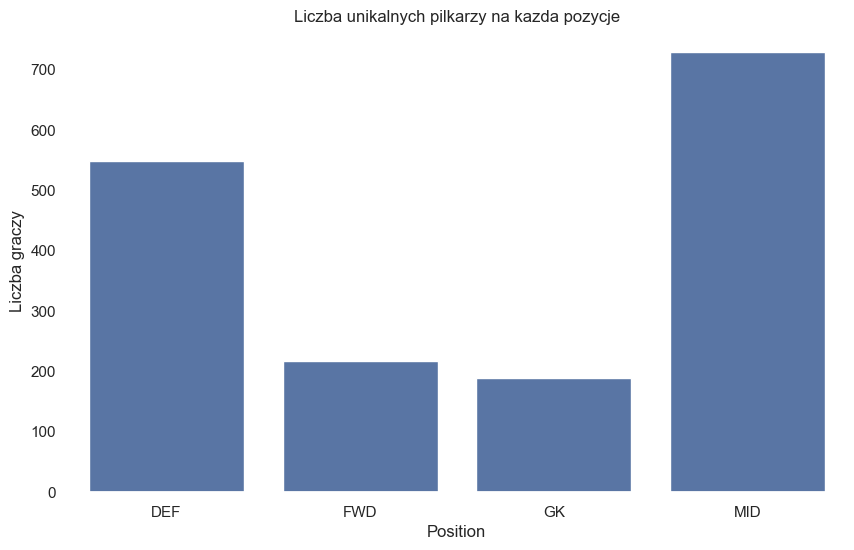

In [14]:
plt.figure(figsize=(10,6))
sns.barplot(data.groupby("position")["name"].nunique())
plt.title("Liczba unikalnych pilkarzy na kazda pozycje")
plt.xlabel("Position")
plt.ylabel("Liczba graczy")

In [15]:
[c for c in data.columns if "points" in c]

['total_points',
 'team_points',
 'opp_points',
 'team_expected_points',
 'opp_expected_points']

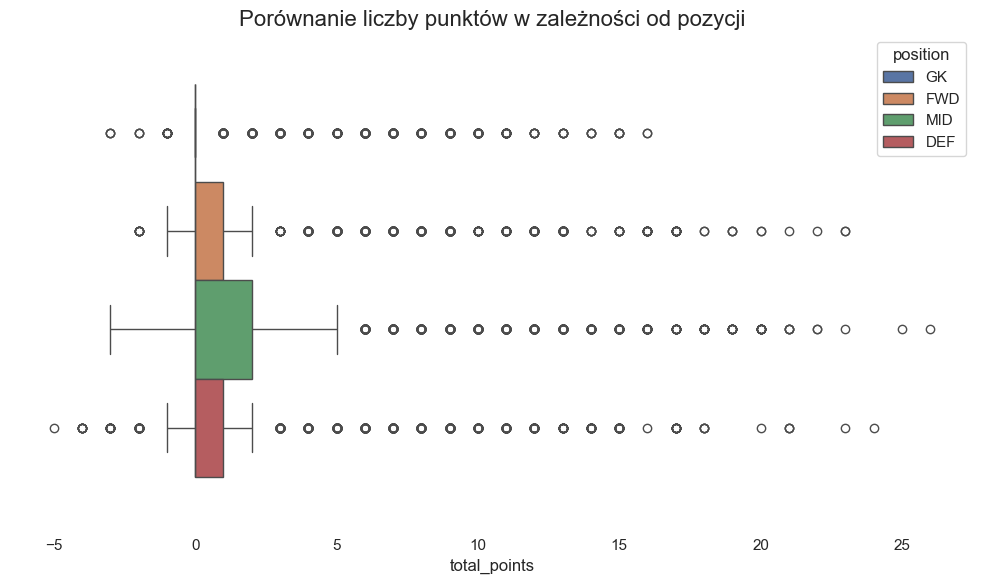

In [16]:
plt.figure(figsize=(10,  6))
sns.boxplot(data=data, x="total_points", hue="position")

plt.title("Porównanie liczby punktów w zależności od pozycji", fontsize=16)

plt.tight_layout()


Text(0.5, 1.0, 'Rozkład Total Points')

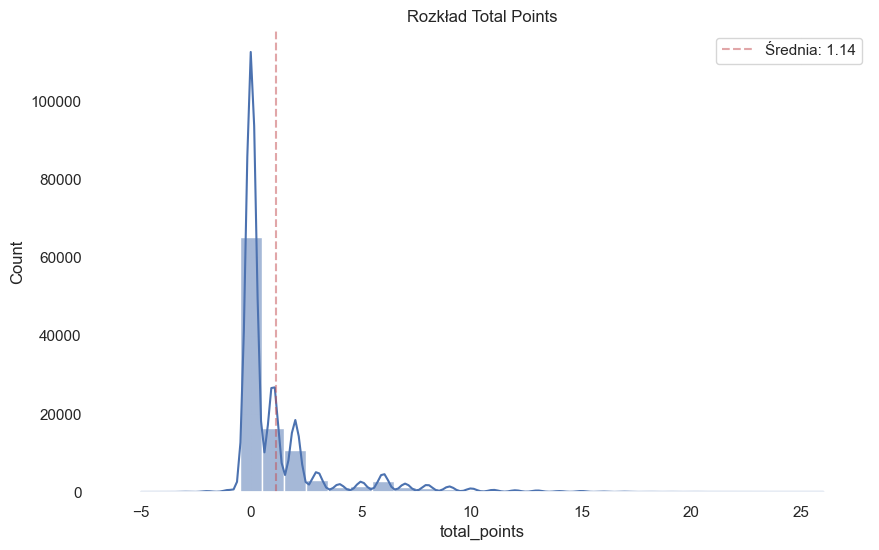

In [17]:
plt.figure(figsize=(10,6))

ax = sns.histplot(data.total_points,
             kde=True,
            #palette="magma",
             discrete=True,
             bins=30)
ax.axvline(data.total_points.mean(), linestyle="--", color="r", alpha=0.5, label=f"Średnia: {data.total_points.mean():.2f}")
plt.legend(loc="upper right")
plt.title("Rozkład Total Points")

<Axes: >

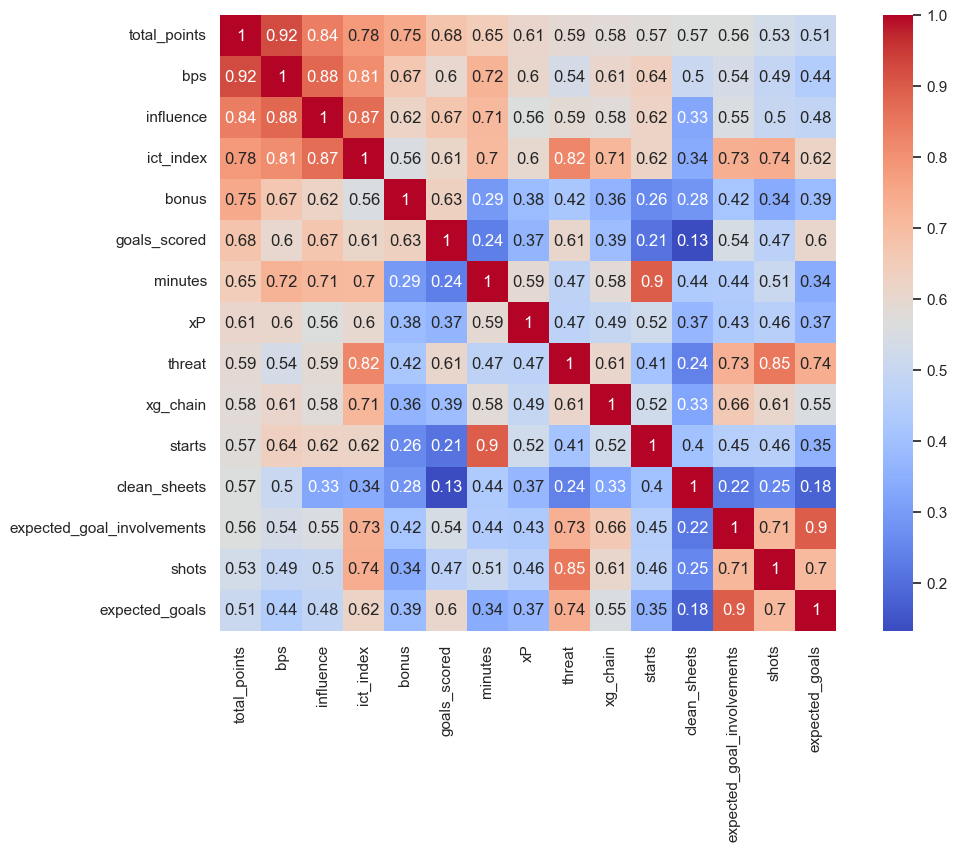

In [18]:
corr = data.select_dtypes(exclude=["object", "string"]).corr().apply(np.abs)
cols = corr["total_points"].sort_values(ascending=False).head(15).index

plt.figure(figsize=(12, 8))
sns.heatmap(corr.loc[cols, cols], annot=True, cmap="coolwarm", square=True)

In [19]:
best_players_plots(df=data,
                   num_players=10,
                   season=2526)

KeyError: 'team_name'

In [18]:
data["value_ratio"] = (data.total_points / data.now_cost).fillna(0)


AttributeError: 'DataFrame' object has no attribute 'now_cost'

In [19]:
data[["name", "value_ratio", "position", "gw", "season"]].sort_values(by="value_ratio", ascending=False).head()

KeyError: "['web_name', 'value_ratio', 'season_id'] not in index"

In [20]:
x_cols = [c for c in data.columns if "expected" in c]

In [21]:
x_cols

['expected_assists',
 'expected_goal_involvements',
 'expected_goals',
 'expected_goals_conceded',
 'team_expected_points',
 'opp_expected_points']

In [22]:
data.columns.to_list()[:10]

['name',
 'position',
 'xP',
 'assists',
 'bonus',
 'bps',
 'clean_sheets',
 'creativity',
 'element',
 'expected_assists']

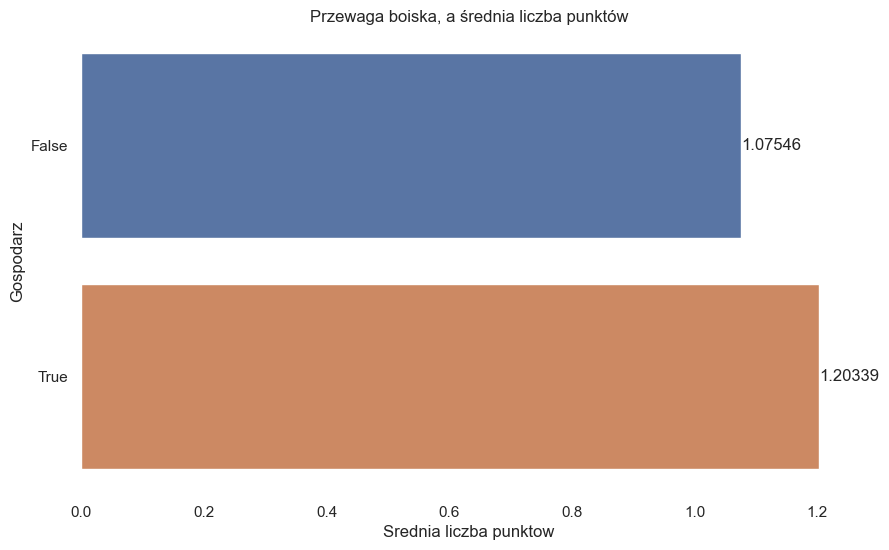

In [23]:
plt.figure(figsize=(10,6))
ax = sns.barplot(
    data=data,
    y="was_home",
    x="total_points",
    hue="was_home",
    estimator="mean",
    legend=False,
    errorbar=None,
    orient="h")

plt.xlabel("Srednia liczba punktow")
plt.ylabel("Gospodarz")

for container in ax.containers:
    ax.bar_label(container)
plt.title("Przewaga boiska, a średnia liczba punktów");

In [24]:
teams_avenue_form = data.groupby(["season", "team_name", "was_home"])["total_points"].mean().reset_index()
teams_avenue_form = teams_avenue_form.pivot(index=["season", "team_name"], columns="was_home", values="total_points")

# Zmień na 1 i 0 jeśli Twoje was_home to zera i jedynki
teams_avenue_form["home_advantage"] = teams_avenue_form[True] - teams_avenue_form[False]

# Zostawiamy nazwy drużyn i sezonu, zamieniając je z powrotem na zwykłe kolumny!
teams_avenue_form.reset_index(inplace=True)

teams_avenue_form.sort_values(by="home_advantage", ascending=False, inplace=True)
teams_avenue_form.columns.name = None

KeyError: 'season_id'

In [ ]:
teams_avenue_form.head()

In [ ]:
teams_avenue_form.tail()

In [ ]:
plt.figure(figsize=(10, 8))
ax =sns.barplot(data=pd.concat([teams_avenue_form[teams_avenue_form.season==2526].head(), teams_avenue_form[teams_avenue_form.season==2526].tail()], axis=0),
            x="home_advantage",
            hue="team_name",
            y="team_name",
            palette=colors_config.team_colors,
            errorbar=None)
plt.title("Największa / Najmniejsza przewaga własnego boiska w obecnym sezonie", fontsize=14)
plt.xlabel("Różnica punktów (Dom - Wyjazd)")
plt.ylabel("")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")


In [ ]:
team_names = [t for t in data[data.season==2526].team_name.unique()]
team_names

In [ ]:
data[data.season==2526].gw.unique()

In [ ]:
[c for c in data.columns if "sele" in c]

In [ ]:
data.position.unique()

In [25]:
data.columns

Index(['name', 'position', 'xP', 'assists', 'bonus', 'bps', 'clean_sheets',
       'creativity', 'element', 'expected_assists',
       'expected_goal_involvements', 'expected_goals',
       'expected_goals_conceded', 'goals_conceded', 'goals_scored',
       'ict_index', 'influence', 'kickoff_time', 'minutes', 'opponent_team',
       'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards',
       'saves', 'selected', 'starts', 'threat', 'total_points',
       'transfers_balance', 'transfers_in', 'transfers_out', 'value',
       'was_home', 'yellow_cards', 'gw', 'code', 'season', 'date',
       'team_score', 'opp_score', 'score_diff', 'player_id', 'shots',
       'xg_chain', 'xg_buildup', 'key_passes', 'team_points', 'opp_points',
       'team_expected_points', 'opp_expected_points', 'team_goals',
       'opp_goals', 'team_xg', 'opp_xg', 'team_np_xg', 'opp_np_xg',
       'team_np_xg_difference', 'opp_np_xg_difference', 'team_ppda',
       'opp_ppda', 'team_deep_completions', 'opp

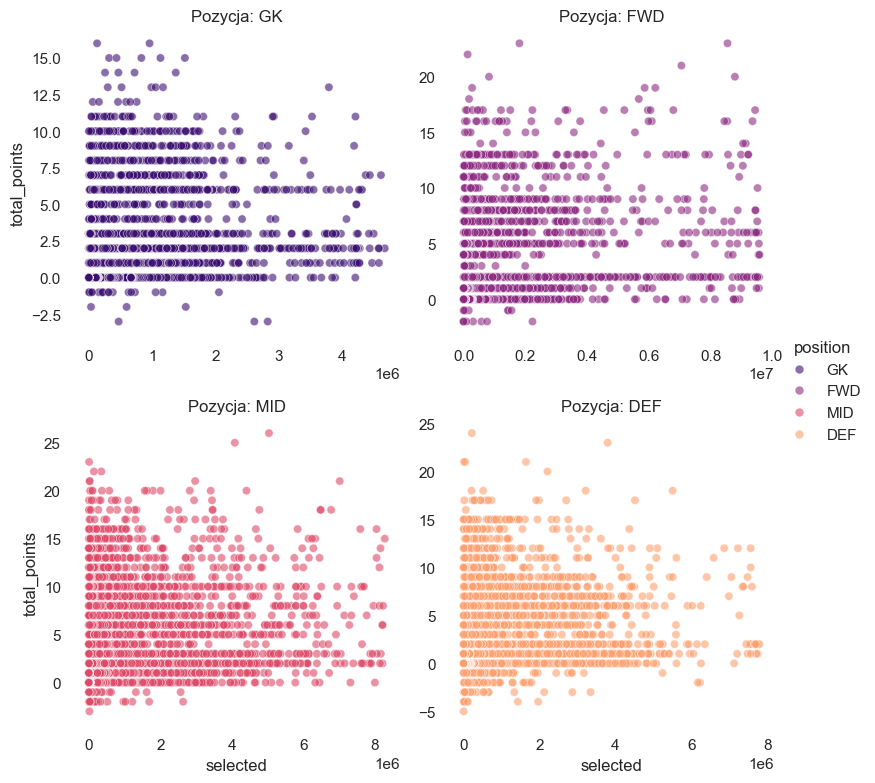

In [26]:
g = sns.relplot(
    data=data,
    x="selected",
    y="total_points",
    col="position",
    hue="position",
    col_wrap=2,
    palette="magma",
    kind="scatter",
    alpha=0.6,
    height=4,
    facet_kws={'sharex': False, 'sharey': False}

)

g.set_titles("Pozycja: {col_name}")

plt.show()

In [37]:
def radar_plot_x_stats(df: pd.DataFrame, players: list[str], stats: list[str], season: int|list[int]=2526):
    if isinstance(season, int) and season:
        season = [season]
    if not players:
        return df

    df = df[(df.season.isin(season)) & (df.name.isin(players))].groupby("name")[stats].mean().reset_index()

    df = pd.melt(
    df,
    id_vars=['name'],
    value_vars=stats,
    var_name="stats",
    value_name='value'

    )

    fig = px.line_polar(
        df,
        r='value',
        theta='stats',
        color='name',
        line_close=True,
        markers=True,
        title=f"Statystyki oczekiwane dla {', '.join(players)} w sezonie {', '.join(map(str, season))}",
        template="plotly_white"
    )

    fig.update_traces(fill='toself', opacity=0.4)
    fig.show()

In [38]:
radar_plot_x_stats(df=data,
                   players=data[data.season == 2526].name.sample(3).tolist(),
                   stats=[c for c in data.columns if "expected" in c])

In [23]:
data.to_parquet(config.TIDY_DATA_PATH)